# Drift-diffusion magnitude comparison

This notebook fits the Barreto-Garcia et al. (2022) numerosity-comparison data with two models from `bauer`:

- **`MagnitudeComparisonModel`** — the static Bayesian-observer model. Subjects draw a noisy log-magnitude estimate per stimulus, the posterior is shrunk toward a prior, and a cumulative-normal choice rule maps the difference distribution to a choice probability.
- **`DDMMagnitudeComparisonModel`** — same cognitive front-end, but the perceived `(diff_mu, diff_sd)` is fed to a Wiener first-passage-time likelihood (via HSSM) instead of a cumulative normal. Choices *and* RTs are modelled jointly.

Drift maps from the cognitive model as

$$v = \frac{\mathrm{post}\_n_2\mu - \mathrm{post}\_n_1\mu}{\sqrt{\sigma_1^2 + \sigma_2^2}}$$

i.e. the subjective signal-to-noise of the perceived log-magnitude difference. We fix the `v_scale` coefficient to 1 (the default) so that `evidence_sd` absorbs the drift scale; with `v_scale` free, the two are strongly correlated and posteriors bloat. The order effect (n1 noisier than n2 because n1 must be held in memory across the ISI) shows up identically in both models: differential prior pulling shifts `diff_mu`.

Both models share the cognitive parameters: `n1_evidence_sd`, `n2_evidence_sd`, prior. The DDM adds `a` (boundary), `z` (start), `t0` (non-decision time). We fit both hierarchically on 6 subjects × 200 trials each, then compare per-subject posteriors of the *shared* cognitive parameters. Hypothesis: the DDM, by jointly using RT, gives tighter (more reliable) posteriors than choice alone.

**Fitting takes ~10 minutes total**, so it's done in a separate script (`notebooks/fit_ddm_garcia.py`). This notebook checks for cached netcdf results and runs the script automatically if they're missing.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import os.path as op
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from bauer.utils.data import load_garcia2022
from bauer.models import MagnitudeComparisonModel, DDMMagnitudeComparisonModel

sns.set_theme(style='ticks', context='notebook')

## Data

`load_garcia2022` returns RTs in seconds with non-responses and trials with implausibly fast RTs (< 150 ms by default) already filtered. Below we use **all 64 subjects** if the cached full fit is present (run `python notebooks/fit_ddm_garcia.py --full`); otherwise the notebook falls back to the smaller 6-subject example fit.

In [2]:
df = load_garcia2022(task='magnitude')
print('full data:', df.shape, '| n subjects:', df.index.get_level_values('subject').nunique())
df[['n1', 'n2', 'choice', 'rt']].head()

full data: (13410, 38) | n subjects: 64


n1  n2  choice     rt
subject format       run trial_nr                       
1       non-symbolic 1   1          7  10    True  0.775
                         2          5  14   False  0.892
                         3          7  14    True  0.611
                         4          7  10    True  0.660
                         5          5  10    True  0.830

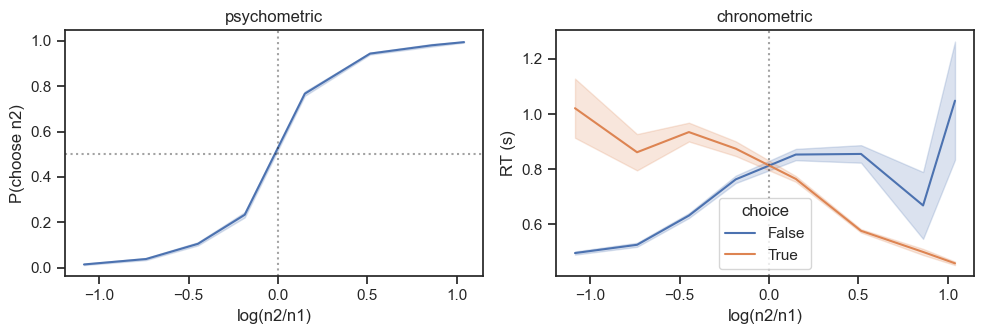

In [3]:
df_plot = df.copy()
df_plot['log_ratio'] = np.log(df_plot['n2'] / df_plot['n1'])
df_plot['log_ratio_bin'] = pd.qcut(df_plot['log_ratio'], q=8).map(lambda x: x.mid)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.lineplot(data=df_plot, x='log_ratio_bin', y='choice', ax=axes[0], errorbar='se')
axes[0].set(ylabel='P(choose n2)', xlabel='log(n2/n1)', title='psychometric')
axes[0].axhline(0.5, color='k', linestyle=':', alpha=0.4)
axes[0].axvline(0.0, color='k', linestyle=':', alpha=0.4)

sns.lineplot(data=df_plot, x='log_ratio_bin', y='rt', hue='choice', ax=axes[1], errorbar='se')
axes[1].set(ylabel='RT (s)', xlabel='log(n2/n1)', title='chronometric')
axes[1].axvline(0.0, color='k', linestyle=':', alpha=0.4)
plt.tight_layout()

## Load cached fits (or run the fit script)

If `notebooks/results/*.nc` doesn't exist, the next cell runs `fit_ddm_garcia.py` for you. Re-running the script (or deleting the netcdf files) will refit. To force a refit, delete the files in `notebooks/results/`.

In [4]:
# Prefer the full 64-subject fit if available; fall back to the small example fit.
NB_DIR = op.dirname(op.abspath(globals().get('__file__', op.join(os.getcwd(), 'placeholder'))))
if not op.isdir(NB_DIR):
    NB_DIR = '.'

for candidate in ['results_full', 'results']:
    cdir = op.join(NB_DIR, candidate)
    if op.exists(op.join(cdir, 'garcia_ddm_idata.nc')):
        RESULTS_DIR = cdir
        break
else:
    RESULTS_DIR = op.join(NB_DIR, 'results')

CHOICE_PATH = op.join(RESULTS_DIR, 'garcia_choice_idata.nc')
DDM_PATH = op.join(RESULTS_DIR, 'garcia_ddm_idata.nc')

if not (op.exists(CHOICE_PATH) and op.exists(DDM_PATH)):
    print('Cached fits not found - running fit_ddm_garcia.py...')
    script = op.join(NB_DIR, 'fit_ddm_garcia.py')
    subprocess.run([sys.executable, script], check=True)

idata_choice = az.from_netcdf(CHOICE_PATH)
idata_ddm = az.from_netcdf(DDM_PATH)
print(f'loaded from {RESULTS_DIR}')
print('  choice idata:', idata_choice.posterior.sizes)
print('  DDM idata:   ', idata_ddm.posterior.sizes)

fit_subjects = idata_ddm.posterior.coords['subject'].values
df = df.loc[df.index.get_level_values('subject').isin(fit_subjects)].copy()
print(f'using {len(df)} trials, {len(fit_subjects)} subjects')

loaded from /Users/gdehol/git/bauer/notebooks/results_full
  choice idata: Frozen({'chain': 2, 'draw': 1000, 'subject': 64})
  DDM idata:    Frozen({'chain': 2, 'draw': 1000, 'subject': 64})
using 13410 trials, 64 subjects


In [5]:
print('--- choice-only model ---')
print(az.summary(idata_choice, var_names=['n1_evidence_sd_mu', 'n2_evidence_sd_mu'], round_to=3))
print('\n--- DDM model ---')
print(az.summary(idata_ddm, var_names=['n1_evidence_sd_mu', 'n2_evidence_sd_mu',
                                        'a_mu', 'z_mu', 't0_mu'], round_to=3))

--- choice-only model ---
                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
n1_evidence_sd_mu  0.299  0.012   0.274    0.320        0.0      0.0   
n2_evidence_sd_mu  0.102  0.015   0.076    0.131        0.0      0.0   

                   ess_bulk  ess_tail  r_hat  
n1_evidence_sd_mu   707.151  1146.727  1.001  
n2_evidence_sd_mu  1600.952   991.033  1.002  

--- DDM model ---
                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
n1_evidence_sd_mu  0.312  0.009   0.294    0.328      0.000    0.000   
n2_evidence_sd_mu  0.117  0.014   0.093    0.144      0.000    0.000   
a_mu               0.880  0.019   0.844    0.914      0.002    0.001   
z_mu               0.501  0.005   0.491    0.510      0.000    0.000   
t0_mu              0.130  0.007   0.117    0.143      0.001    0.000   

                   ess_bulk  ess_tail  r_hat  
n1_evidence_sd_mu   439.162   681.367  1.007  
n2_evidence_sd_mu   986.230  1095.103  1.001  
a_mu                161

## Compare per-subject posteriors

For each subject and shared parameter (`n1_evidence_sd`, `n2_evidence_sd`), extract the posterior mean and 94 % HDI from both fits. If RT genuinely adds reliability, the DDM HDIs should be tighter than the choice-only ones.

In [6]:
def per_subject_summary(idata, var):
    """Return DataFrame indexed by subject with mean, hdi_low, hdi_high, hdi_width."""
    post = idata.posterior[var]
    mean = post.mean(dim=['chain', 'draw']).to_pandas()
    hdi = az.hdi(idata, var_names=[var], hdi_prob=0.94)[var].to_pandas()
    out = pd.DataFrame({
        'mean': mean,
        'hdi_low': hdi.iloc[:, 0],
        'hdi_high': hdi.iloc[:, 1],
    })
    out['hdi_width'] = out['hdi_high'] - out['hdi_low']
    return out

# Per-draw combined evidence noise: sqrt(sd1^2 + sd2^2). This is the diff_sd that
# enters drift = (post_n2_mu - post_n1_mu) / diff_sd, so it's the quantity the
# psychometric / chronometric curves are most directly informative about.
def add_combined_sd(idata):
    if 'evidence_sd_combined' not in idata.posterior:
        c = (idata.posterior['n1_evidence_sd']**2 +
             idata.posterior['n2_evidence_sd']**2) ** 0.5
        idata.posterior['evidence_sd_combined'] = c

add_combined_sd(idata_choice)
add_combined_sd(idata_ddm)

variables = ['n1_evidence_sd', 'n2_evidence_sd', 'evidence_sd_combined']
summaries = {}
for var in variables:
    summaries[var] = pd.concat({
        'choice': per_subject_summary(idata_choice, var),
        'ddm':    per_subject_summary(idata_ddm, var),
    }, axis=1)
summaries['evidence_sd_combined'].head()

choice                                     ddm                      \
             mean   hdi_low  hdi_high hdi_width      mean   hdi_low  hdi_high   
subject                                                                         
1        0.290696  0.234355  0.346569  0.112214  0.302554  0.270098  0.335873   
2        0.298977  0.243258  0.352301  0.109043  0.335630  0.296620  0.376800   
3        0.357538  0.289133  0.420270  0.131138  0.407407  0.359079  0.459413   
4        0.420404  0.343439  0.492356  0.148917  0.308670  0.267981  0.351297   
5        0.369495  0.310598  0.435402  0.124804  0.416005  0.367985  0.462915   

                   
        hdi_width  
subject            
1        0.065775  
2        0.080180  
3        0.100334  
4        0.083316  
5        0.094929

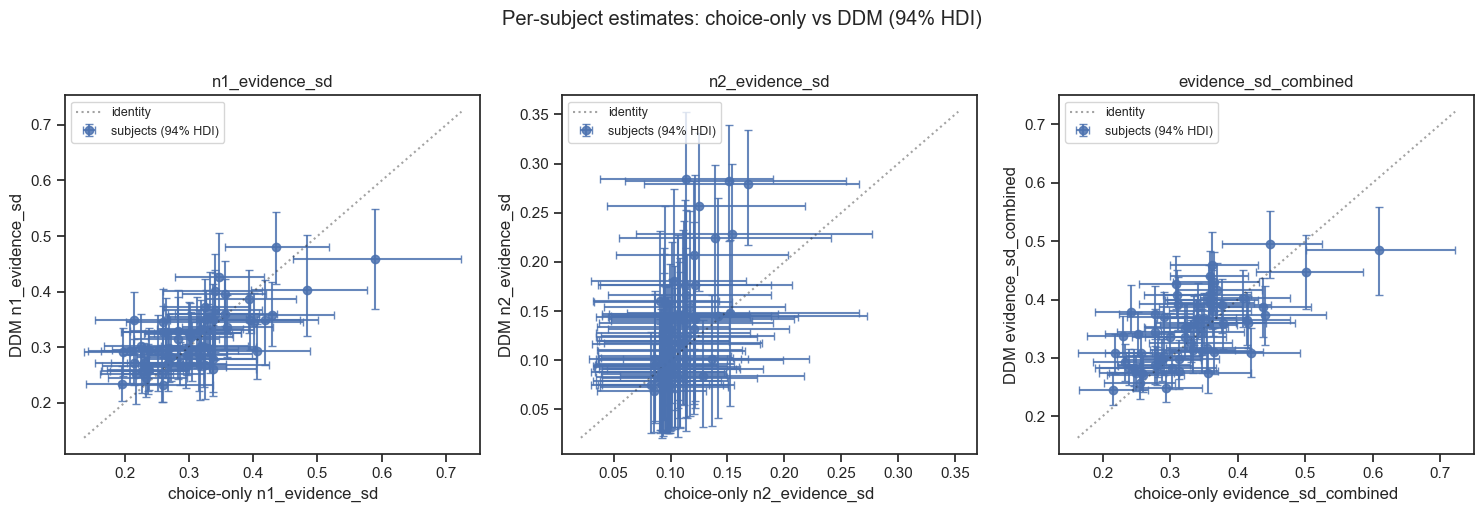

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axes, variables):
    s = summaries[var]
    x_err = np.vstack([s['choice', 'mean'] - s['choice', 'hdi_low'],
                       s['choice', 'hdi_high'] - s['choice', 'mean']])
    y_err = np.vstack([s['ddm', 'mean']    - s['ddm', 'hdi_low'],
                       s['ddm', 'hdi_high'] - s['ddm', 'mean']])
    ax.errorbar(s['choice', 'mean'], s['ddm', 'mean'],
                xerr=x_err, yerr=y_err, fmt='o', capsize=3,
                color='C0', alpha=0.85, label='subjects (94% HDI)')
    lo = min(s['choice', 'hdi_low'].min(), s['ddm', 'hdi_low'].min())
    hi = max(s['choice', 'hdi_high'].max(), s['ddm', 'hdi_high'].max())
    ax.plot([lo, hi], [lo, hi], 'k:', alpha=0.4, label='identity')
    ax.set_xlabel(f'choice-only {var}')
    ax.set_ylabel(f'DDM {var}')
    ax.set_title(var)
    ax.legend(loc='upper left', fontsize=9)
fig.suptitle('Per-subject estimates: choice-only vs DDM (94% HDI)', y=1.02)
plt.tight_layout()

In [8]:
rows = []
for var in variables:
    s = summaries[var]
    rows.append({
        'parameter': var,
        'median HDI width (choice)': s['choice', 'hdi_width'].median(),
        'median HDI width (DDM)':    s['ddm', 'hdi_width'].median(),
    })
hdi_compare = pd.DataFrame(rows).set_index('parameter')
hdi_compare['ratio (DDM / choice)'] = (
    hdi_compare['median HDI width (DDM)'] / hdi_compare['median HDI width (choice)']
)
hdi_compare.round(3)

,median HDI width (choice),median HDI width (DDM),ratio (DDM / choice)
parameter,,,
n1_evidence_sd,0.137,0.109,0.794
n2_evidence_sd,0.131,0.147,1.130
evidence_sd_combined,0.120,0.080,0.665


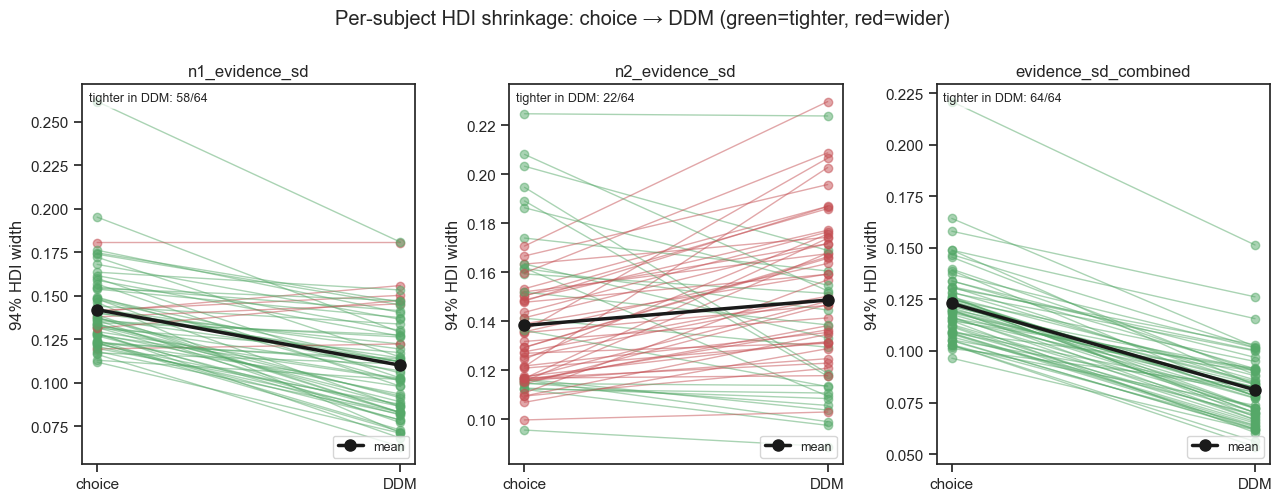

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=False)
for ax, var in zip(axes, variables):
    s = summaries[var]
    choice_w = s['choice', 'hdi_width']
    ddm_w = s['ddm', 'hdi_width']
    for sub in choice_w.index:
        cw, dw = choice_w[sub], ddm_w[sub]
        color = 'C2' if dw < cw else 'C3'
        ax.plot([0, 1], [cw, dw], 'o-', color=color, alpha=0.5, linewidth=1)
    ax.plot([0, 1], [choice_w.mean(), ddm_w.mean()],
            'ko-', linewidth=2.5, markersize=8, label='mean')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['choice', 'DDM'])
    ax.set_ylabel('94% HDI width')
    ax.set_title(var)
    n_tighter = (ddm_w < choice_w).sum()
    n_total = len(choice_w)
    ax.text(0.02, 0.98, f'tighter in DDM: {n_tighter}/{n_total}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.legend(loc='lower right', fontsize=9)
fig.suptitle('Per-subject HDI shrinkage: choice → DDM (green=tighter, red=wider)', y=1.00)
plt.tight_layout()

## Order effect

Both fits should show `n1_evidence_sd > n2_evidence_sd` consistently across subjects: n1 picks up memory noise on top of perceptual noise because it has to be held across the ISI before n2 arrives.

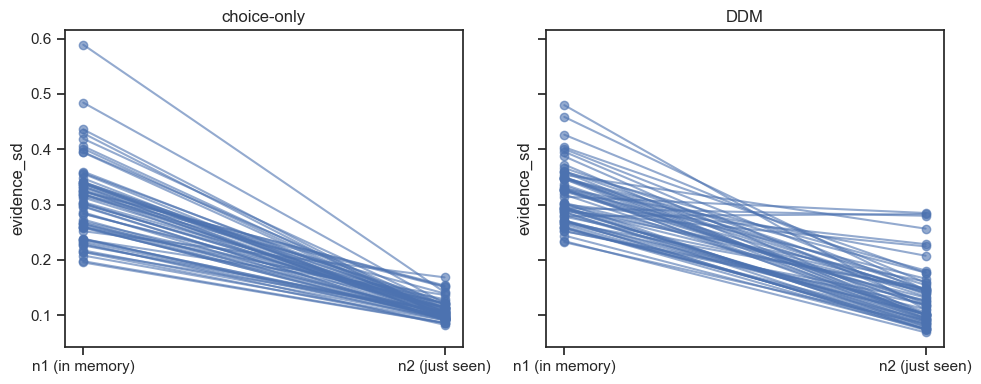

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, (label, idata) in zip(axes, [('choice-only', idata_choice), ('DDM', idata_ddm)]):
    s1 = per_subject_summary(idata, 'n1_evidence_sd')
    s2 = per_subject_summary(idata, 'n2_evidence_sd')
    for sub in s1.index:
        ax.plot([0, 1], [s1.loc[sub, 'mean'], s2.loc[sub, 'mean']],
                'o-', color='C0', alpha=0.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['n1 (in memory)', 'n2 (just seen)'])
    ax.set_ylabel('evidence_sd')
    ax.set_title(label)
plt.tight_layout()

## Posterior predictive check (DDM)

Simulate `(rt, choice)` under the posterior and compare to observed psychometric and chronometric curves.

In [11]:
m_ddm = DDMMagnitudeComparisonModel(paradigm=df, fit_seperate_evidence_sd=True,
                                     fit_v_scale=False)
m_ddm.build_estimation_model(data=df, hierarchical=True)
ppc = m_ddm.ppc(df, idata_ddm, n_posterior_samples=200, random_seed=0,
                progressbar=False)
ppc.head()

simulated_rt  simulated_choice
subject format       run trial_nr ppc_sample                                
1       non-symbolic 1   1        0               1.326475              True
                         2        0               1.072573              True
                         3        0               0.682166              True
                         4        0               2.041716              True
                         5        0               0.400600              True

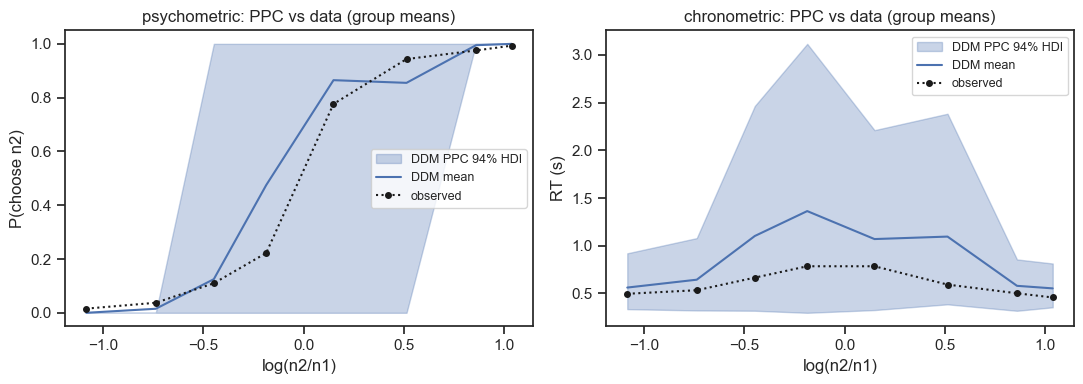

In [12]:
from bauer.utils.bayes import summarize_ppc_group

# Attach paradigm cols + binned predictor
ppc_with_paradigm = ppc.join(df[['n1', 'n2']])
ppc_with_paradigm['log_ratio'] = np.log(ppc_with_paradigm['n2'] / ppc_with_paradigm['n1'])
ppc_with_paradigm['log_ratio_bin'] = pd.qcut(ppc_with_paradigm['log_ratio'], q=8).map(lambda x: x.mid).astype(float)
df_obs = df.copy()
df_obs['log_ratio'] = np.log(df_obs['n2'] / df_obs['n1'])
df_obs['log_ratio_bin'] = pd.qcut(df_obs['log_ratio'], q=8).map(lambda x: x.mid).astype(float)

# Reshape long -> wide (rows = trials, columns = ppc_sample int).
# Then for each variable, summarize_ppc_group does the proper two-step averaging:
# (1) per-(subject, bin, sample) mean,
# (2) cross-subject mean per (bin, sample),
# (3) HDI across samples per bin.
def _wide(col):
    w = ppc_with_paradigm[col].unstack('ppc_sample')
    return w.join(ppc_with_paradigm[['log_ratio_bin']].droplevel('ppc_sample').drop_duplicates()).reset_index()

ppc_rt_wide = _wide('simulated_rt')
ppc_ch_wide = _wide('simulated_choice').astype({c: float for c in _wide('simulated_choice').select_dtypes('bool').columns}, errors='ignore')

summary_rt = summarize_ppc_group(ppc_rt_wide, condition_cols=['log_ratio_bin'], hdi_prob=0.94)
summary_ch = summarize_ppc_group(ppc_ch_wide, condition_cols=['log_ratio_bin'], hdi_prob=0.94)

# Observed: same group-then-pool structure (per-subject mean per bin, then cross-subject mean)
def obs_group_mean(df, value_col, condition_col, subject_col='subject'):
    return df.groupby([subject_col, condition_col], observed=True)[value_col].mean().groupby(condition_col, observed=True).mean()
obs_choice = obs_group_mean(df_obs, 'choice', 'log_ratio_bin').sort_index()
obs_rt = obs_group_mean(df_obs, 'rt', 'log_ratio_bin').sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
s = summary_ch.sort_index()
ax.fill_between(s.index, s['hdi025'], s['hdi975'], alpha=0.3, color='C0', label='DDM PPC 94% HDI')
ax.plot(s.index, s['p_predicted'], color='C0', label='DDM mean')
ax.plot(obs_choice.index, obs_choice.values, 'k:', marker='o', markersize=4, label='observed')
ax.set(ylabel='P(choose n2)', xlabel='log(n2/n1)', title='psychometric: PPC vs data (group means)')
ax.legend(fontsize=9)

ax = axes[1]
s = summary_rt.sort_index()
ax.fill_between(s.index, s['hdi025'], s['hdi975'], alpha=0.3, color='C0', label='DDM PPC 94% HDI')
ax.plot(s.index, s['p_predicted'], color='C0', label='DDM mean')
ax.plot(obs_rt.index, obs_rt.values, 'k:', marker='o', markersize=4, label='observed')
ax.set(ylabel='RT (s)', xlabel='log(n2/n1)', title='chronometric: PPC vs data (group means)')
ax.legend(fontsize=9)
plt.tight_layout()

## Size effect: RT vs magnitude at matched difficulty

The Bayesian-observer DDM has a strong prediction: with Weber-style noise (σ scales with magnitude), drift = log-ratio / sqrt(σ₁²+σ₂²) shrinks for larger magnitudes at *fixed log-ratio* — so RTs should slow down. This is the classic *size effect*. We bin trials by geometric-mean magnitude and overlay observed vs DDM-predicted chronometric curves.

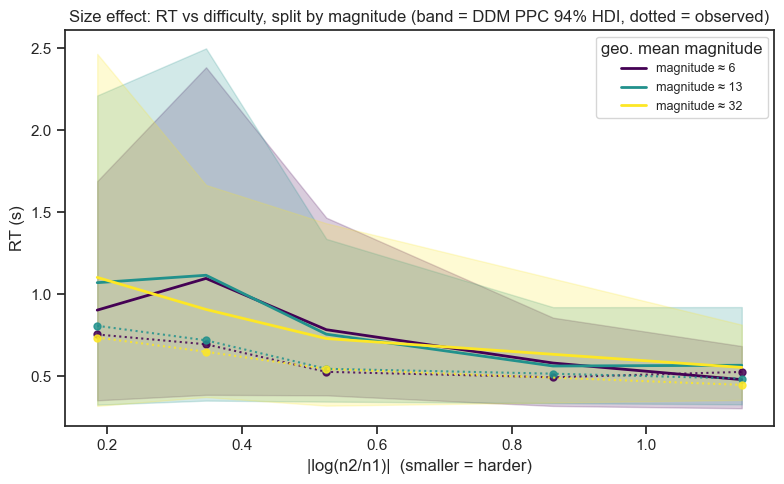

In [13]:
def add_size_bins(d):
    d = d.copy()
    d['abs_log_ratio'] = np.abs(np.log(d['n2'] / d['n1']))
    d['abs_log_ratio_bin'] = pd.qcut(d['abs_log_ratio'], q=5, duplicates='drop').map(lambda x: x.mid).astype(float)
    d['geo_mean'] = np.sqrt(d['n1'] * d['n2'])
    d['mag_bin'] = pd.qcut(d['geo_mean'], q=3, duplicates='drop').map(lambda x: round(x.mid, 1)).astype(float)
    return d

ppc_full = add_size_bins(ppc.join(df[['n1', 'n2']]))
df_obs2 = add_size_bins(df)

def _wide_2d(col, frame):
    w = frame[col].unstack('ppc_sample')
    cond = frame[['mag_bin', 'abs_log_ratio_bin']].droplevel('ppc_sample').drop_duplicates()
    return w.join(cond).reset_index()

summary_rt_2d = summarize_ppc_group(_wide_2d('simulated_rt', ppc_full),
                                     condition_cols=['mag_bin', 'abs_log_ratio_bin'],
                                     hdi_prob=0.94)
obs_rt_2d = (df_obs2.groupby(['subject', 'mag_bin', 'abs_log_ratio_bin'], observed=True)['rt'].mean()
             .groupby(['mag_bin', 'abs_log_ratio_bin'], observed=True).mean())

mag_bins = sorted(summary_rt_2d.index.get_level_values('mag_bin').unique())
fig, ax = plt.subplots(figsize=(8, 5))
for i, mb in enumerate(mag_bins):
    s = summary_rt_2d.xs(mb, level='mag_bin').sort_index()
    color = plt.cm.viridis(i / max(1, len(mag_bins) - 1))
    ax.fill_between(s.index, s['hdi025'], s['hdi975'], alpha=0.2, color=color)
    ax.plot(s.index, s['p_predicted'], color=color, label=f'magnitude ≈ {mb:.0f}', linewidth=2)
    o = obs_rt_2d.xs(mb, level='mag_bin').sort_index()
    ax.plot(o.index, o.values, ':', color=color, marker='o', markersize=5, alpha=0.85)
ax.set_xlabel('|log(n2/n1)|  (smaller = harder)')
ax.set_ylabel('RT (s)')
ax.set_title('Size effect: RT vs difficulty, split by magnitude (band = DDM PPC 94% HDI, dotted = observed)')
ax.legend(title='geo. mean magnitude', fontsize=9)
plt.tight_layout()